# LogistiX – Enterprise Supply Chain Intelligence Platform

## Notebook 05 — Exploratory Data Analysis (EDA)

### Phase

Exploratory Data Analysis

### Objective

The objective of this notebook is to analyze supply chain operations, logistics performance, customer behavior, sales trends, profitability, delivery performance, and regional operations using business-focused exploratory data analysis.

---

### Workflow

1. Import Libraries
2. Load Feature Engineered Dataset
3. Business KPI Overview
4. Sales Analysis
5. Profit Analysis
6. Customer Analysis
7. Product Analysis
8. Shipping Analysis
9. Delivery Analysis
10. Regional Analysis
11. Operational Insights
12. Business Summary

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

pd.set_option("display.max_columns", None)
pd.set_option("display.width",1000)

print("LogistiX - Exploratory Data Analysis Started")

LogistiX - Exploratory Data Analysis Started


In [2]:
file_path="../data/processed/feature_engineered_supply_chain_dataset.csv"

df=pd.read_csv(file_path)

print(df.shape)

(180519, 67)


In [3]:
df.head()

,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,customer_country,customer_email,customer_fname,customer_id,customer_lname,customer_password,customer_segment,customer_state,customer_street,customer_zipcode,department_id,department_name,latitude,longitude,market,order_city,order_country,order_customer_id,order_date_dateorders,order_id,order_item_cardprod_id,order_item_discount,order_item_discount_rate,order_item_id,order_item_product_price,order_item_profit_ratio,order_item_quantity,sales,order_item_total,order_profit_per_order,order_region,order_state,order_status,order_zipcode,product_card_id,product_category_id,product_description,product_image,product_name,product_price,product_status,shipping_date_dateorders,shipping_mode,shipping_lead_time,delivery_delay,on_time_delivery,profit_margin,order_value_category,customer_type,high_value_order,weekend_order,order_month,order_year,shipping_speed,profit_category,discount_category,quantity_category
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,2018-01-31 22:56:00,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,3,-1,On Time,27.841342,Premium,B2C,1,0,January,2018,Standard,Profit,Low,Single
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,2018-01-13 12:27:00,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,5,1,Delayed,-75.999999,Premium,B2C,1,1,January,2018,Standard,Loss,Low,Single
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,2018-01-13 12:06:00,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class,4,0,On Time,-75.600305,Premium,B2C,1,1,January,2018,Standard,Loss,Low,Single
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,2018-01-13 11:45:00,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class,3,-1,On Time,6.974829,Premium,B2B,1,1,January,2018,Standard,Profit,Low,Single
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,2018-01-13 11:24:00,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class,2,-2,On Time,40.948896,Premium,B2B,1,1,January,2018,Fast,Profit,Low,Single


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 67 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   type                         180519 non-null  object 
 1   days_for_shipping_real       180519 non-null  int64  
 2   days_for_shipment_scheduled  180519 non-null  int64  
 3   benefit_per_order            180519 non-null  float64
 4   sales_per_customer           180519 non-null  float64
 5   delivery_status              180519 non-null  object 
 6   late_delivery_risk           180519 non-null  int64  
 7   category_id                  180519 non-null  int64  
 8   category_name                180519 non-null  object 
 9   customer_city                180519 non-null  object 
 10  customer_country             180519 non-null  object 
 11  customer_email               180519 non-null  object 
 12  customer_fname               180519 non-null  object 
 13 

# Executive Business KPIs

In [5]:
total_orders=df["order_id"].nunique()

total_customers=df["customer_id"].nunique()

total_products=df["product_card_id"].nunique()

total_sales=df["sales"].sum()

total_profit=df["order_profit_per_order"].sum()

average_order_value=df["sales"].mean()

In [6]:
kpis=pd.DataFrame({

"KPI":[
"Total Orders",
"Total Customers",
"Total Products",
"Total Sales",
"Total Profit",
"Average Order Value"
],

"Value":[
total_orders,
total_customers,
total_products,
round(total_sales,2),
round(total_profit,2),
round(average_order_value,2)
]

})

kpis

,KPI,Value
0,Total Orders,65752.00
1,Total Customers,20652.00
2,Total Products,118.00
3,Total Sales,36784735.01
4,Total Profit,3966902.97
5,Average Order Value,203.77


In [7]:
kpis.style.hide(axis="index")

KPI,Value
Total Orders,65752.000000
Total Customers,20652.000000
Total Products,118.000000
Total Sales,36784735.010000
Total Profit,3966902.970000
Average Order Value,203.770000


# Sales Analysis

## Business Question

How are sales distributed across products, categories, regions, and time?

In [8]:
df["sales"].sum()

np.float64(36784735.01337984)

In [9]:
monthly_sales = (
    df.groupby("order_month")["sales"]
    .sum()
    .reset_index()
)

monthly_sales

,order_month,sales
0,April,3.053996e+06
1,August,3.187032e+06
2,December,2.599160e+06
3,February,2.888088e+06
4,January,3.459246e+06
5,July,3.188170e+06
6,June,3.059152e+06
7,March,3.125112e+06
8,May,3.185364e+06
9,November,2.703625e+06


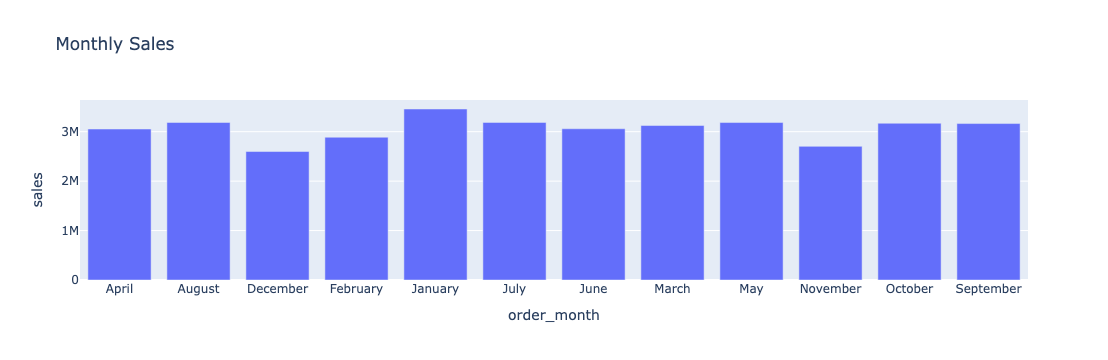

In [10]:
fig = px.bar(
    monthly_sales,
    x="order_month",
    y="sales",
    title="Monthly Sales"
)

fig.show()

In [11]:
top_products = (
    df.groupby("product_name")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products

,product_name,sales
0,Field & Stream Sportsman 16 Gun Fire Safe,6.929654e+06
1,Perfect Fitness Perfect Rip Deck,4.421143e+06
2,Diamondback Women's Serene Classic Comfort Bi,4.118426e+06
3,Nike Men's Free 5.0+ Running Shoe,3.667633e+06
4,Nike Men's Dri-FIT Victory Golf Polo,3.147800e+06
5,Pelican Sunstream 100 Kayak,3.099845e+06
6,Nike Men's CJ Elite 2 TD Football Cleat,2.891758e+06
7,O'Brien Men's Neoprene Life Vest,2.888994e+06
8,Under Armour Girls' Toddler Spine Surge Runni,1.269083e+06
9,Dell Laptop,6.630000e+05


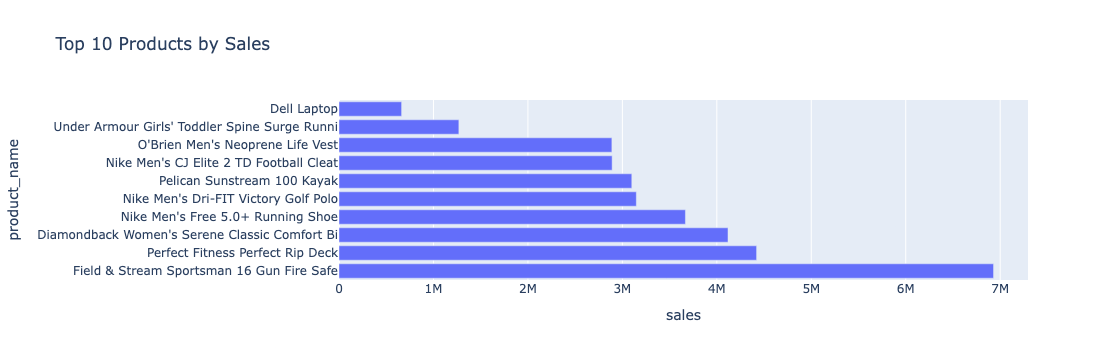

In [12]:
fig = px.bar(
    top_products,
    x="sales",
    y="product_name",
    orientation="h",
    title="Top 10 Products by Sales"
)

fig.show()

In [13]:
category_sales = (
    df.groupby("category_name")["sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_sales

,category_name,sales
0,Fishing,6.929654e+06
1,Cleats,4.431943e+06
2,Camping & Hiking,4.118426e+06
3,Cardio Equipment,3.694843e+06
4,Women's Apparel,3.147800e+06
5,Water Sports,3.113845e+06
6,Men's Footwear,2.891758e+06
7,Indoor/Outdoor Games,2.888994e+06
8,Shop By Sport,1.309522e+06
9,Computers,6.630000e+05


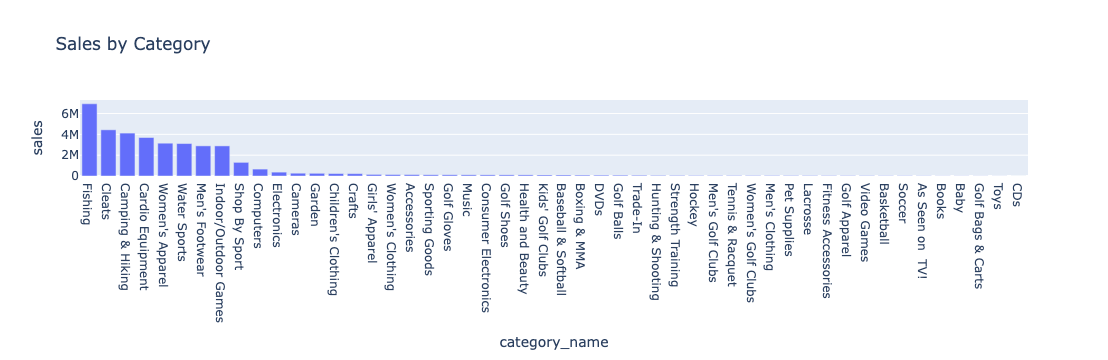

In [14]:
fig = px.bar(
    category_sales,
    x="category_name",
    y="sales",
    title="Sales by Category"
)

fig.show()

In [15]:
segment_sales = (
    df.groupby("customer_segment")["sales"]
    .sum()
    .reset_index()
)

segment_sales

,customer_segment,sales
0,Consumer,1.909579e+07
1,Corporate,1.116841e+07
2,Home Office,6.520538e+06


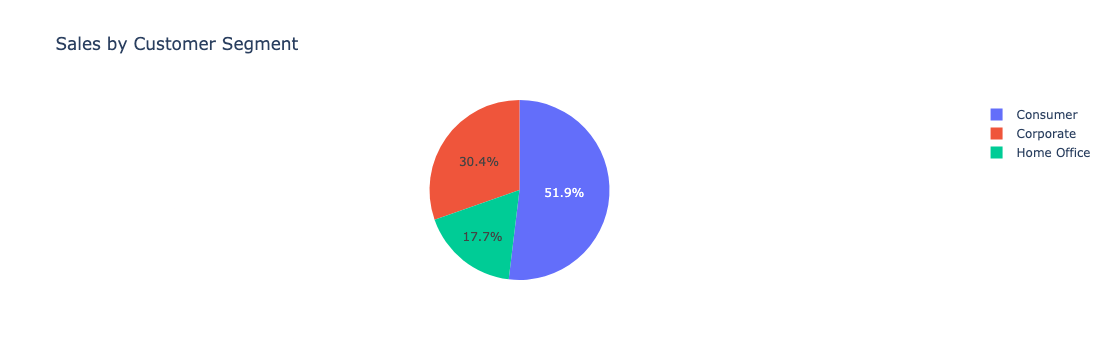

In [16]:
fig = px.pie(
    segment_sales,
    names="customer_segment",
    values="sales",
    title="Sales by Customer Segment"
)

fig.show()

In [17]:
market_sales = (
    df.groupby("market")["sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

market_sales

,market,sales
0,Europe,1.087240e+07
1,LATAM,1.027761e+07
2,Pacific Asia,8.273744e+06
3,USCA,5.066529e+06
4,Africa,2.294453e+06


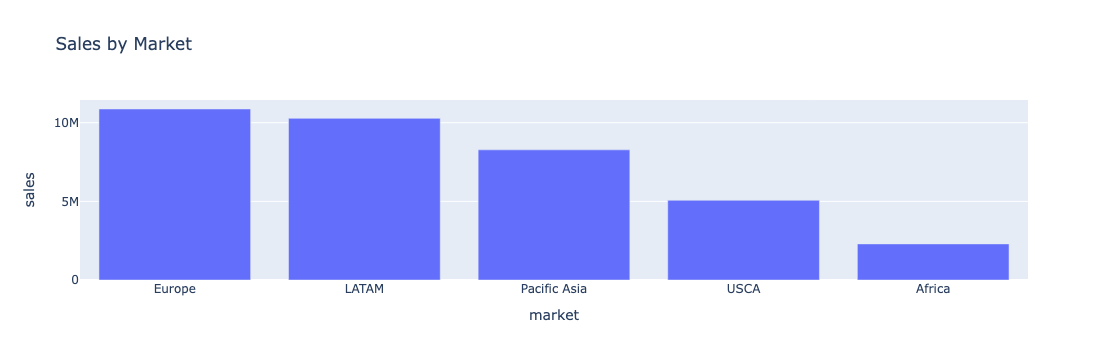

In [18]:
fig = px.bar(
    market_sales,
    x="market",
    y="sales",
    title="Sales by Market"
)

fig.show()

In [19]:
region_sales = (
    df.groupby("order_region")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

region_sales

,order_region,sales
0,Western Europe,5.894381e+06
1,Central America,5.665712e+06
2,South America,2.960881e+06
3,Northern Europe,2.155831e+06
4,Southern Europe,2.047919e+06
5,Oceania,2.016654e+06
6,Southeast Asia,1.932496e+06
7,Caribbean,1.651019e+06
8,West of USA,1.571416e+06
9,South Asia,1.553681e+06


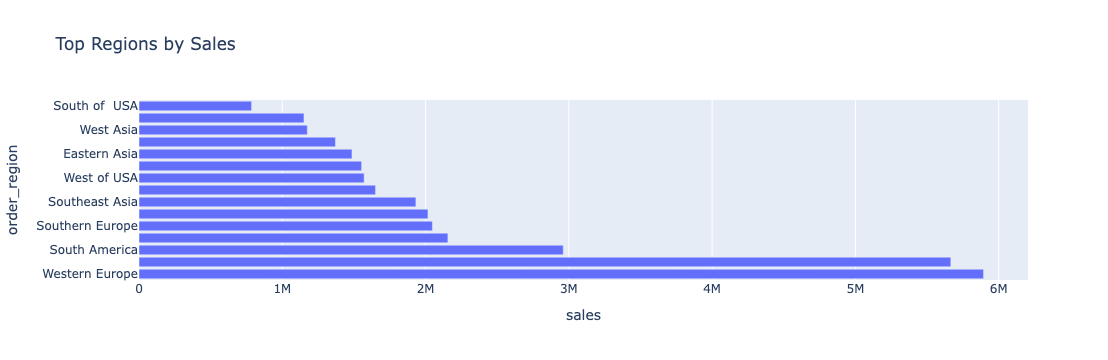

In [20]:
fig = px.bar(
    region_sales,
    x="sales",
    y="order_region",
    orientation="h",
    title="Top Regions by Sales"
)

fig.show()

# Sales Analysis Summary

## Key Business Insights

- Monthly sales trend identified
- Best-selling products identified
- Highest revenue categories identified
- Customer segment contribution analyzed
- Market-wise revenue analyzed
- Top performing regions identified

# Profit Analysis

## Business Question

How profitable is the business across products, categories, regions, and customer segments?

In [21]:
df["order_profit_per_order"].sum()

np.float64(3966902.974050357)

In [22]:
monthly_profit = (
    df.groupby("order_month")["order_profit_per_order"]
    .sum()
    .reset_index()
)

monthly_profit

,order_month,order_profit_per_order
0,April,339021.360056
1,August,360210.470630
2,December,281481.869563
3,February,301061.220935
4,January,367127.430615
5,July,348592.480100
6,June,324742.520726
7,March,333727.100652
8,May,337878.660269
9,November,281757.810287


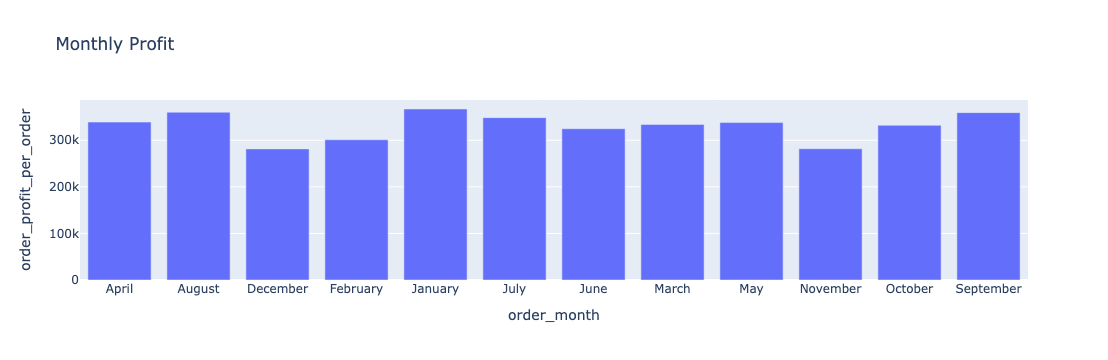

In [23]:
fig = px.bar(
    monthly_profit,
    x="order_month",
    y="order_profit_per_order",
    title="Monthly Profit"
)

fig.show()

In [24]:
category_profit = (
    df.groupby("category_name")["order_profit_per_order"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_profit

,category_name,order_profit_per_order
0,Fishing,756220.767190
1,Cleats,494636.919791
2,Camping & Hiking,427455.568106
3,Cardio Equipment,383011.098485
4,Women's Apparel,350421.029567
5,Water Sports,325146.960038
6,Indoor/Outdoor Games,318451.430554
7,Men's Footwear,311902.820214
8,Shop By Sport,129813.960315
9,Computers,69656.810171


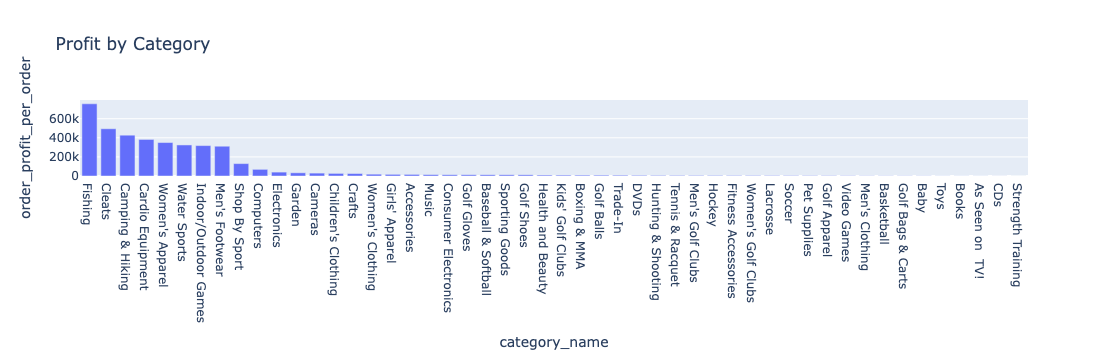

In [25]:
fig = px.bar(
    category_profit,
    x="category_name",
    y="order_profit_per_order",
    title="Profit by Category"
)

fig.show()

In [26]:
top_profit_products = (
    df.groupby("product_name")["order_profit_per_order"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_profit_products

,product_name,order_profit_per_order
0,Field & Stream Sportsman 16 Gun Fire Safe,756220.767190
1,Perfect Fitness Perfect Rip Deck,493828.299782
2,Diamondback Women's Serene Classic Comfort Bi,427455.568106
3,Nike Men's Free 5.0+ Running Shoe,379915.818503
4,Nike Men's Dri-FIT Victory Golf Polo,350421.029567
5,Pelican Sunstream 100 Kayak,324076.370020
6,O'Brien Men's Neoprene Life Vest,318451.430554
7,Nike Men's CJ Elite 2 TD Football Cleat,311902.820214
8,Under Armour Girls' Toddler Spine Surge Runni,126278.510299
9,Dell Laptop,69656.810171


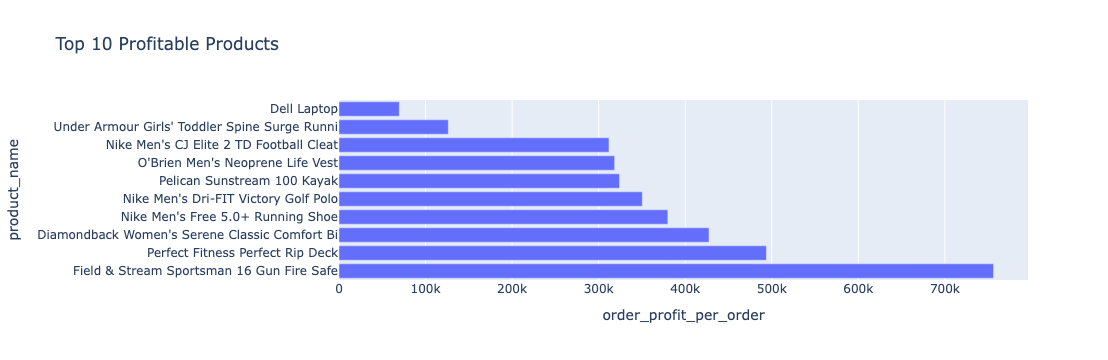

In [27]:
fig = px.bar(
    top_profit_products,
    x="order_profit_per_order",
    y="product_name",
    orientation="h",
    title="Top 10 Profitable Products"
)

fig.show()

In [28]:
segment_profit = (
    df.groupby("customer_segment")["order_profit_per_order"]
    .sum()
    .reset_index()
)

segment_profit

,customer_segment,order_profit_per_order
0,Consumer,2.073488e+06
1,Corporate,1.202575e+06
2,Home Office,6.908403e+05


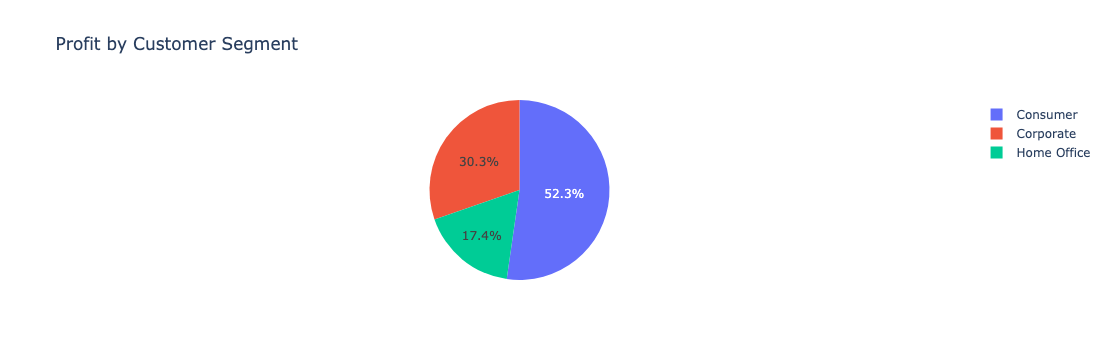

In [29]:
fig = px.pie(
    segment_profit,
    names="customer_segment",
    values="order_profit_per_order",
    title="Profit by Customer Segment"
)

fig.show()

In [30]:
market_profit = (
    df.groupby("market")["order_profit_per_order"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

market_profit

,market,order_profit_per_order
0,Europe,1.169443e+06
1,LATAM,1.123322e+06
2,Pacific Asia,8.577534e+05
3,USCA,5.643138e+05
4,Africa,2.520712e+05


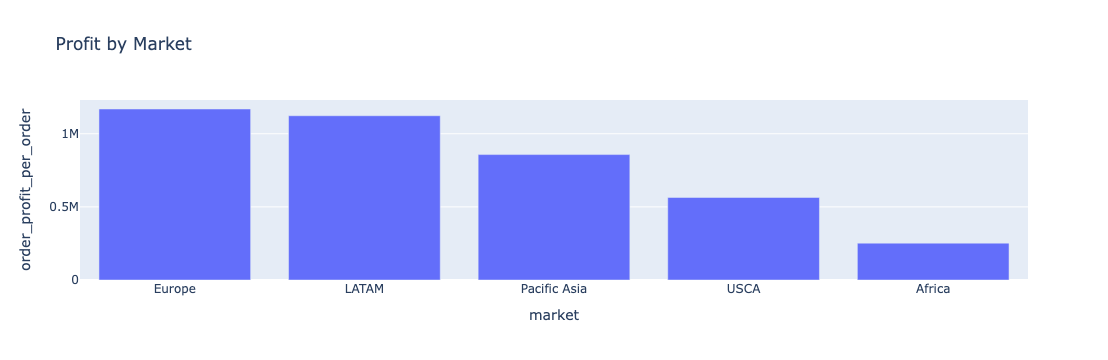

In [31]:
fig = px.bar(
    market_profit,
    x="market",
    y="order_profit_per_order",
    title="Profit by Market"
)

fig.show()

In [32]:
region_profit = (
    df.groupby("order_region")["order_profit_per_order"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

region_profit

,order_region,order_profit_per_order
0,Western Europe,625446.080548
1,Central America,616341.570651
2,South America,335154.400817
3,Northern Europe,233450.600647
4,Southern Europe,230829.229883
5,Southeast Asia,211342.819786
6,Oceania,201478.020484
7,Caribbean,171825.640024
8,South Asia,165703.900124
9,West of USA,164940.660455


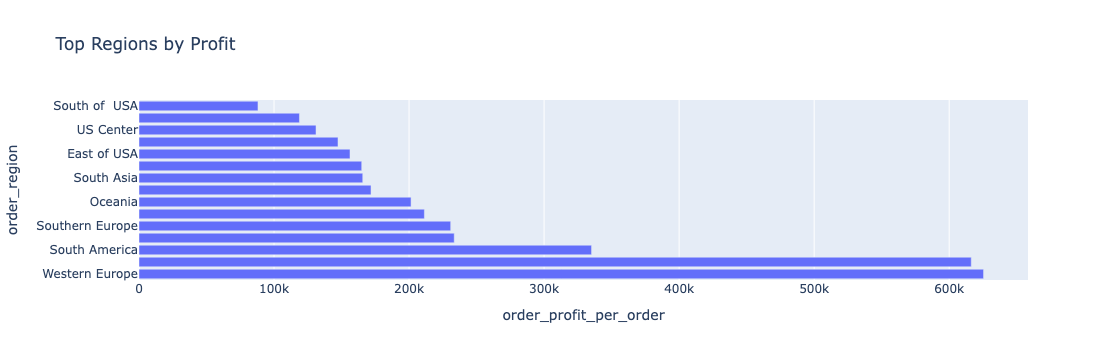

In [33]:
fig = px.bar(
    region_profit,
    x="order_profit_per_order",
    y="order_region",
    orientation="h",
    title="Top Regions by Profit"
)

fig.show()

# Profit Analysis Summary

## Key Business Insights

- Overall business profit calculated
- Monthly profit trend analyzed
- Most profitable categories identified
- Most profitable products identified
- Customer segment profitability analyzed
- Market-wise profit compared
- Top profit-generating regions identified

# Customer Analysis

## Business Question

Who are the most valuable customers and how does customer behavior vary across different segments, regions, and markets?

In [34]:
df["customer_id"].nunique()

20652

In [35]:
customer_segment = (
    df.groupby("customer_segment")["customer_id"]
    .nunique()
    .reset_index(name="customers")
)

customer_segment

,customer_segment,customers
0,Consumer,10695
1,Corporate,6239
2,Home Office,3718


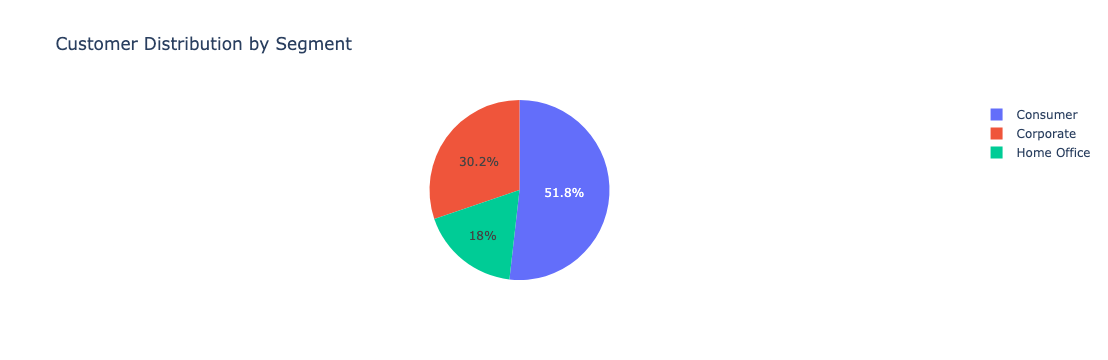

In [36]:
fig = px.pie(
    customer_segment,
    names="customer_segment",
    values="customers",
    title="Customer Distribution by Segment"
)

fig.show()

In [37]:
customer_market = (
    df.groupby("market")["customer_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="customers")
)

customer_market

,market,customers
0,Pacific Asia,13267
1,Europe,11657
2,LATAM,9325
3,USCA,6256
4,Africa,3311


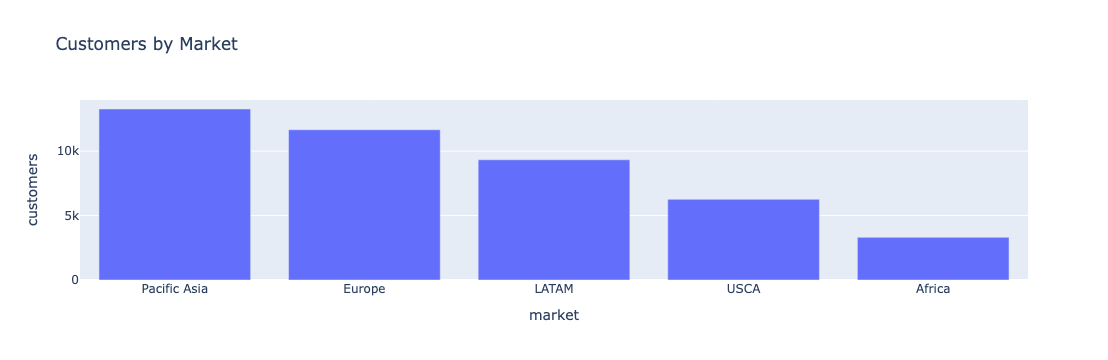

In [38]:
fig = px.bar(
    customer_market,
    x="market",
    y="customers",
    title="Customers by Market"
)

fig.show()

In [39]:
top_customer_country = (
    df.groupby("customer_country")["customer_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="customers")
)

top_customer_country

,customer_country,customers
0,EE. UU.,12719
1,Puerto Rico,7933


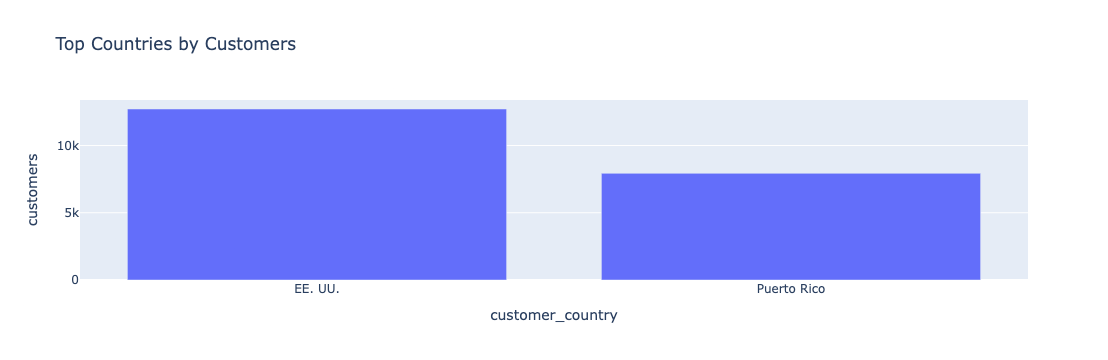

In [40]:
fig = px.bar(
    top_customer_country,
    x="customer_country",
    y="customers",
    title="Top Countries by Customers"
)

fig.show()

In [41]:
top_customer_state = (
    df.groupby("customer_state")["customer_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="customers")
)

top_customer_state

,customer_state,customers
0,PR,7933
1,CA,3318
2,NY,1278
3,TX,1088
4,IL,855
5,FL,583
6,OH,465
7,MI,427
8,PA,426
9,NJ,381


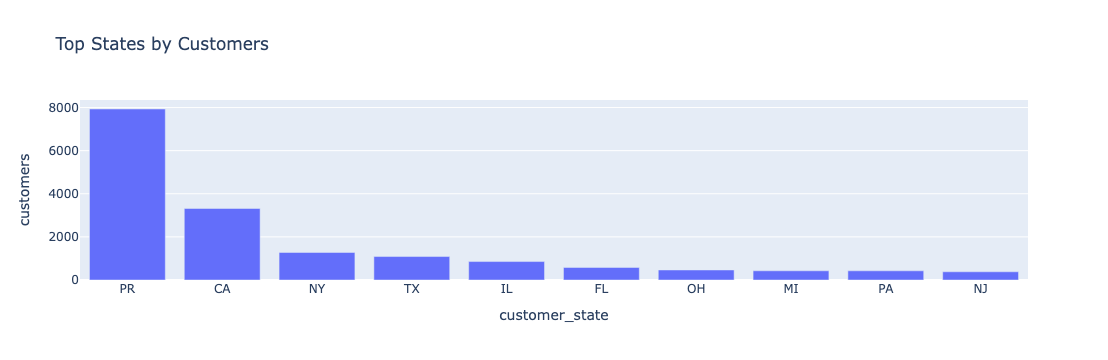

In [42]:
fig = px.bar(
    top_customer_state,
    x="customer_state",
    y="customers",
    title="Top States by Customers"
)

fig.show()

In [43]:
top_customers = (
    df.groupby("customer_id")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_customers

,customer_id,sales
0,791,10524.170178
1,9371,9299.030207
2,8766,9296.140186
3,1657,9223.710152
4,2641,9130.920224
5,1288,9019.110199
6,3710,9019.100208
7,4249,8918.850134
8,5654,8904.950211
9,5624,8761.980183


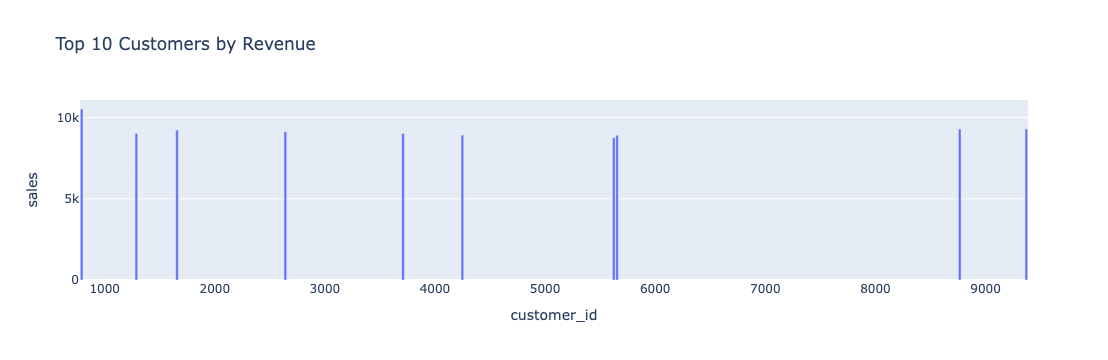

In [44]:
fig = px.bar(
    top_customers,
    x="customer_id",
    y="sales",
    title="Top 10 Customers by Revenue"
)

fig.show()

In [45]:
customer_type = (
    df.groupby("customer_type")
    .size()
    .reset_index(name="orders")
)

customer_type

,customer_type,orders
0,B2B,87015
1,B2C,93504


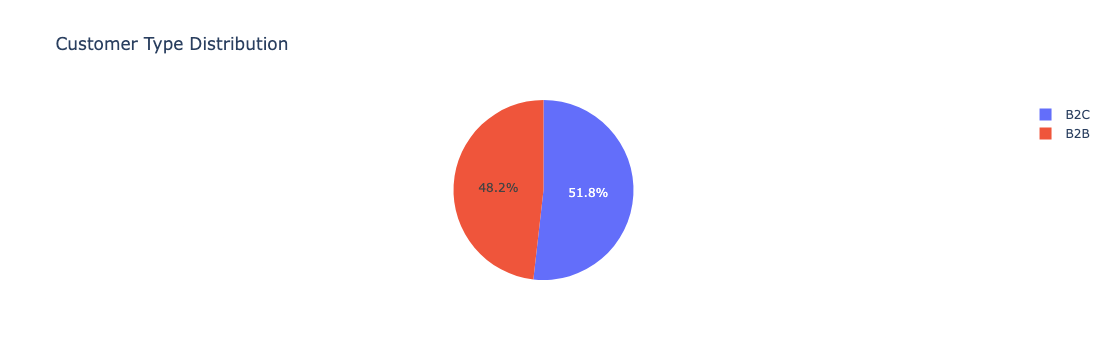

In [46]:
fig = px.pie(
    customer_type,
    names="customer_type",
    values="orders",
    title="Customer Type Distribution"
)

fig.show()

# Customer Analysis Summary

## Key Business Insights

- Total unique customers identified
- Customer segments analyzed
- Market-wise customer distribution analyzed
- Top customer countries identified
- Top customer states identified
- Highest revenue customers identified
- B2B vs B2C customer distribution analyzed

# Shipping & Delivery Analysis

## Business Question

How efficient is the shipping process, and where are the major delivery bottlenecks across shipping modes, markets, and regions?

In [47]:
shipping_mode = (
    df.groupby("shipping_mode")
    .size()
    .reset_index(name="orders")
)

shipping_mode

,shipping_mode,orders
0,First Class,27814
1,Same Day,9737
2,Second Class,35216
3,Standard Class,107752


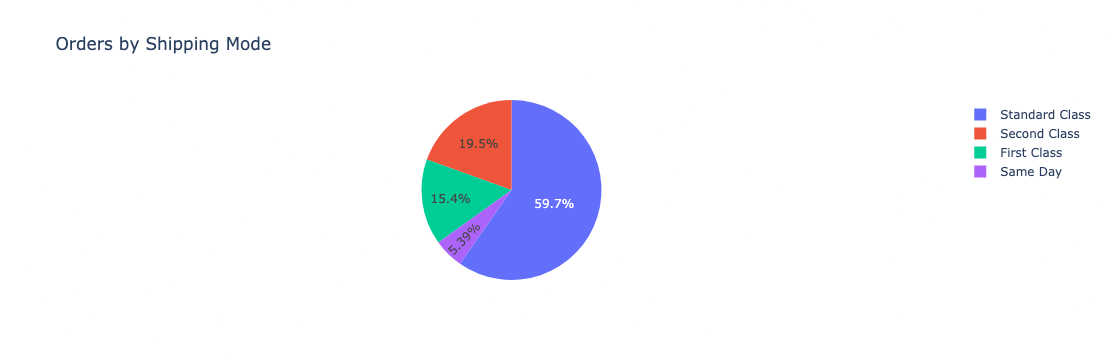

In [48]:
fig = px.pie(
    shipping_mode,
    names="shipping_mode",
    values="orders",
    title="Orders by Shipping Mode"
)

fig.show()

In [49]:
shipping_days = (
    df.groupby("shipping_mode")["days_for_shipping_real"]
    .mean()
    .reset_index()
)

shipping_days

,shipping_mode,days_for_shipping_real
0,First Class,2.000000
1,Same Day,0.478279
2,Second Class,3.990828
3,Standard Class,3.995907


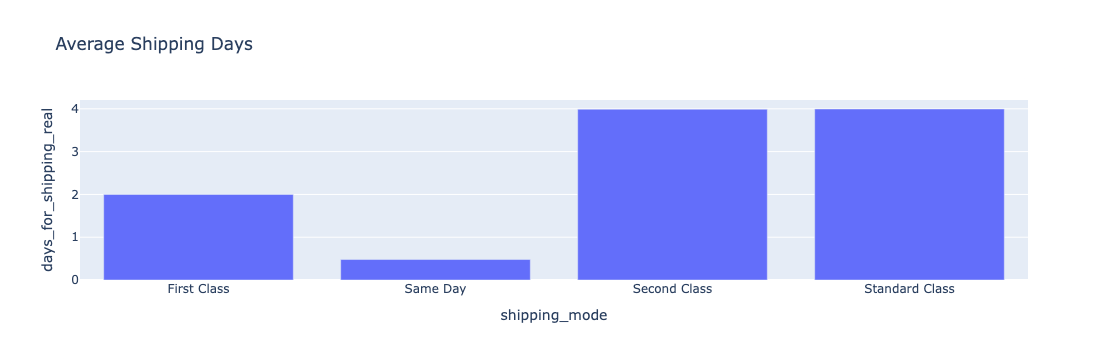

In [50]:
fig = px.bar(
    shipping_days,
    x="shipping_mode",
    y="days_for_shipping_real",
    title="Average Shipping Days"
)

fig.show()

In [51]:
delivery_status = (
    df.groupby("delivery_status")
    .size()
    .reset_index(name="orders")
)

delivery_status

,delivery_status,orders
0,Advance shipping,41592
1,Late delivery,98977
2,Shipping canceled,7754
3,Shipping on time,32196


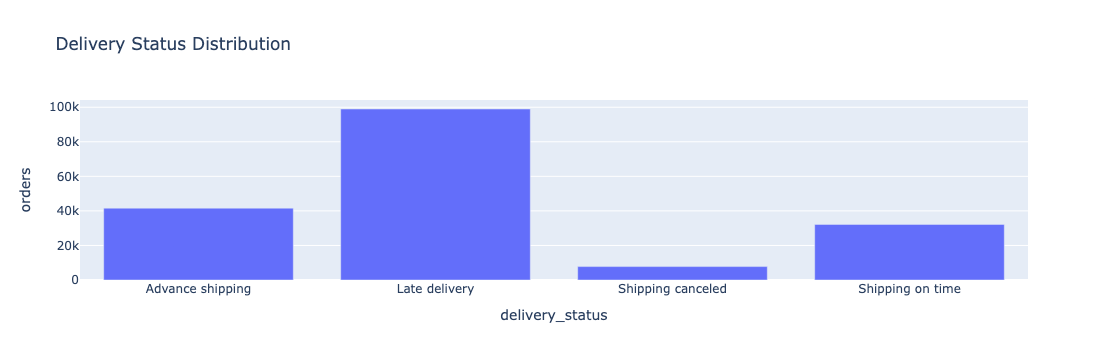

In [52]:
fig = px.bar(
    delivery_status,
    x="delivery_status",
    y="orders",
    title="Delivery Status Distribution"
)

fig.show()

In [53]:
late_delivery = (
    df.groupby("late_delivery_risk")
    .size()
    .reset_index(name="orders")
)

late_delivery

,late_delivery_risk,orders
0,0,81542
1,1,98977


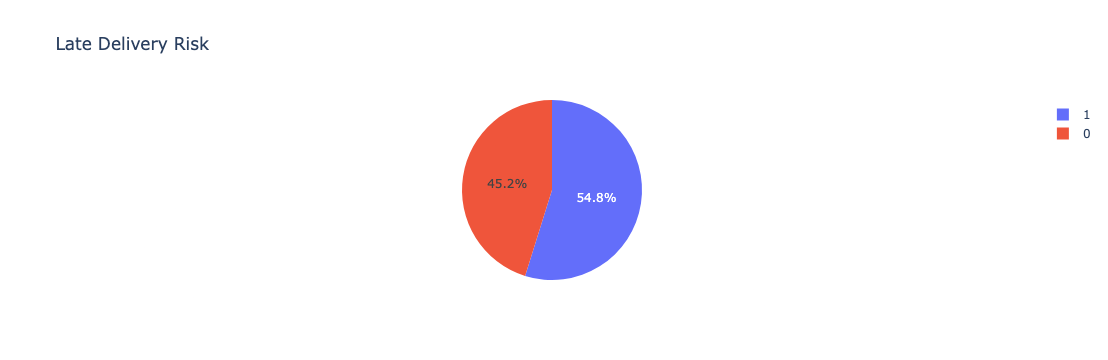

In [54]:
fig = px.pie(
    late_delivery,
    names="late_delivery_risk",
    values="orders",
    title="Late Delivery Risk"
)

fig.show()

In [55]:
delay = (
    df.groupby("shipping_mode")["delivery_delay"]
    .mean()
    .reset_index()
)

delay

,shipping_mode,delivery_delay
0,First Class,1.000000
1,Same Day,0.478279
2,Second Class,1.990828
3,Standard Class,-0.004093


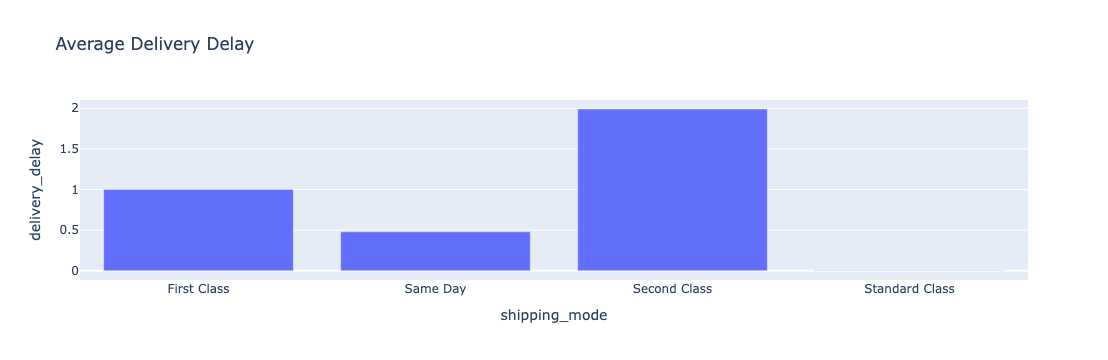

In [56]:
fig = px.bar(
    delay,
    x="shipping_mode",
    y="delivery_delay",
    title="Average Delivery Delay"
)

fig.show()

In [57]:
shipping_speed = (
    df.groupby("shipping_speed")
    .size()
    .reset_index(name="orders")
)

shipping_speed

,shipping_speed,orders
0,Fast,61275
1,Slow,28723
2,Standard,85441


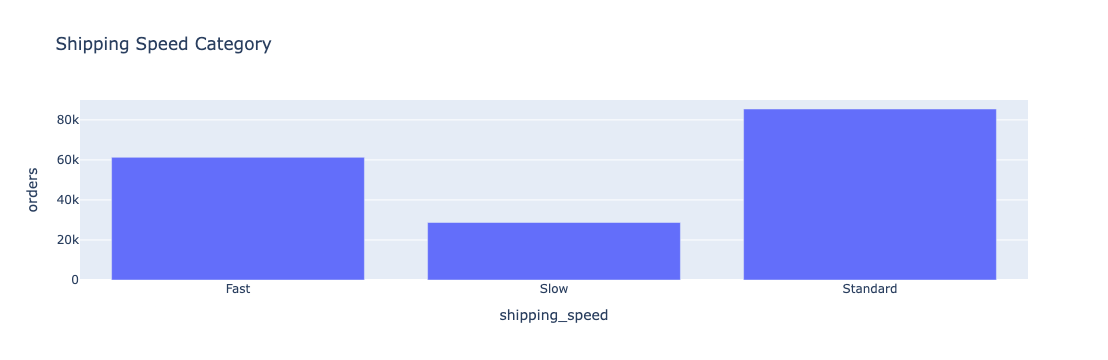

In [58]:
fig = px.bar(
    shipping_speed,
    x="shipping_speed",
    y="orders",
    title="Shipping Speed Category"
)

fig.show()

In [59]:
on_time = (
    df.groupby("on_time_delivery")
    .size()
    .reset_index(name="orders")
)

on_time

,on_time_delivery,orders
0,Delayed,103400
1,On Time,77119


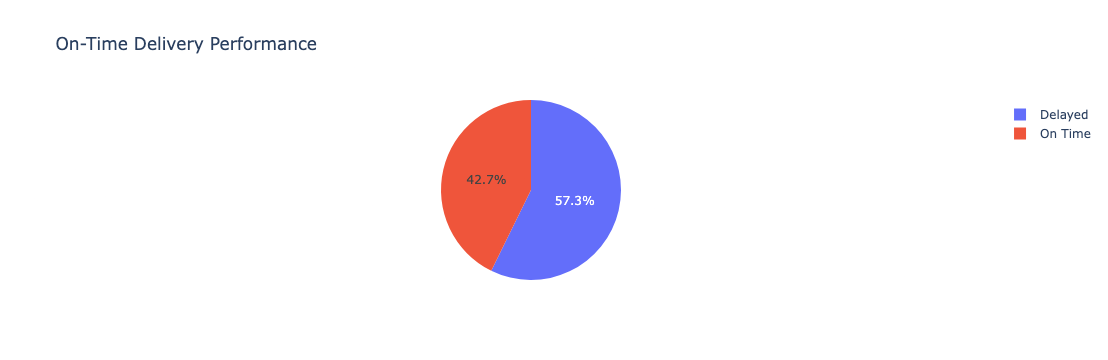

In [60]:
fig = px.pie(
    on_time,
    names="on_time_delivery",
    values="orders",
    title="On-Time Delivery Performance"
)

fig.show()

# Shipping & Delivery Summary

## Key Business Insights

- Shipping mode utilization analyzed
- Average shipping duration evaluated
- Delivery status distribution analyzed
- Late delivery risk assessed
- Shipping delay measured
- Shipping speed categorized
- On-time delivery performance evaluated

# Product & Category Analysis

## Business Question

Which products and categories drive revenue, profitability, and customer demand?

In [61]:
top_quantity_products = (
    df.groupby("product_name")["order_item_quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_quantity_products

,product_name,order_item_quantity
0,Perfect Fitness Perfect Rip Deck,73698
1,Nike Men's Dri-FIT Victory Golf Polo,62956
2,O'Brien Men's Neoprene Life Vest,57803
3,Nike Men's Free 5.0+ Running Shoe,36680
4,Under Armour Girls' Toddler Spine Surge Runni,31735
5,Nike Men's CJ Elite 2 TD Football Cleat,22246
6,Field & Stream Sportsman 16 Gun Fire Safe,17325
7,Pelican Sunstream 100 Kayak,15500
8,Diamondback Women's Serene Classic Comfort Bi,13729
9,ENO Atlas Hammock Straps,998


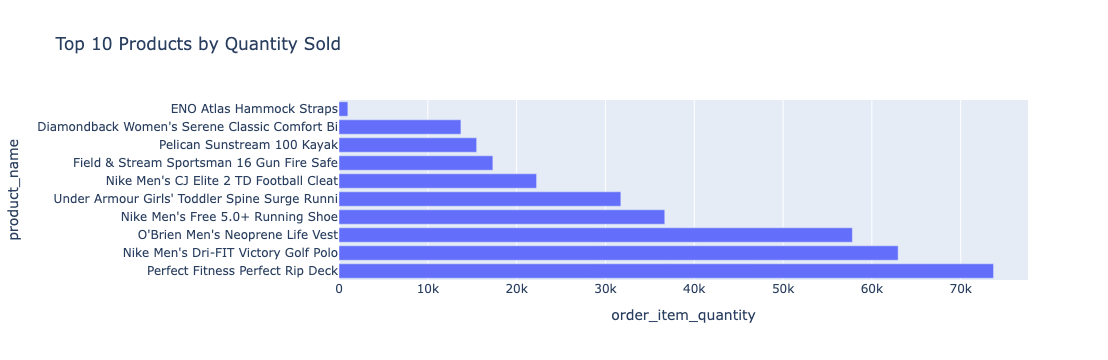

In [62]:
fig = px.bar(
    top_quantity_products,
    x="order_item_quantity",
    y="product_name",
    orientation="h",
    title="Top 10 Products by Quantity Sold"
)

fig.show()

In [63]:
category_orders = (
    df.groupby("category_name")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="orders")
)

category_orders

,category_name,orders
0,Cleats,20386
1,Men's Footwear,18783
2,Women's Apparel,17869
3,Indoor/Outdoor Games,16623
4,Fishing,15164
5,Water Sports,13758
6,Camping & Hiking,12299
7,Cardio Equipment,11355
8,Shop By Sport,10136
9,Electronics,3061


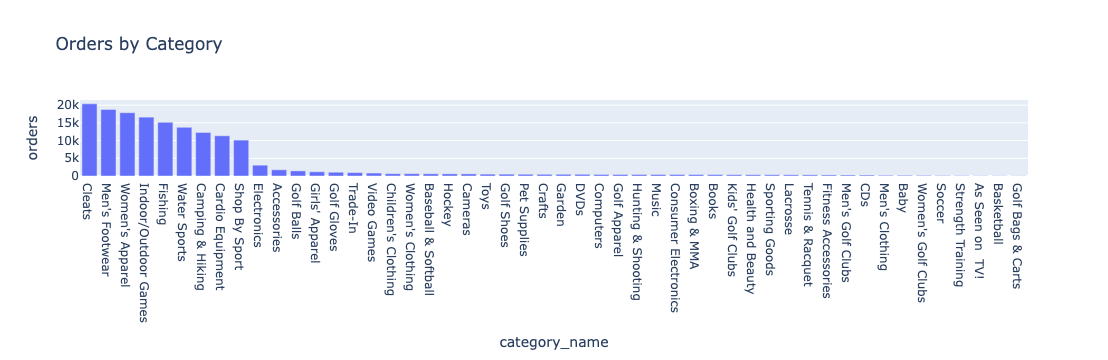

In [64]:
fig = px.bar(
    category_orders,
    x="category_name",
    y="orders",
    title="Orders by Category"
)

fig.show()

In [65]:
department_sales = (
    df.groupby("department_name")["sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

department_sales

,department_name,sales
0,Fan Shop,1.711387e+07
1,Apparel,7.976255e+06
2,Golf,4.609028e+06
3,Footwear,4.006499e+06
4,Outdoors,1.253351e+06
5,Technology,1.039599e+06
6,Fitness,3.970509e+05
7,Discs Shop,2.288877e+05
8,Health and Beauty,1.060805e+05
9,Pet Shop,4.152480e+04


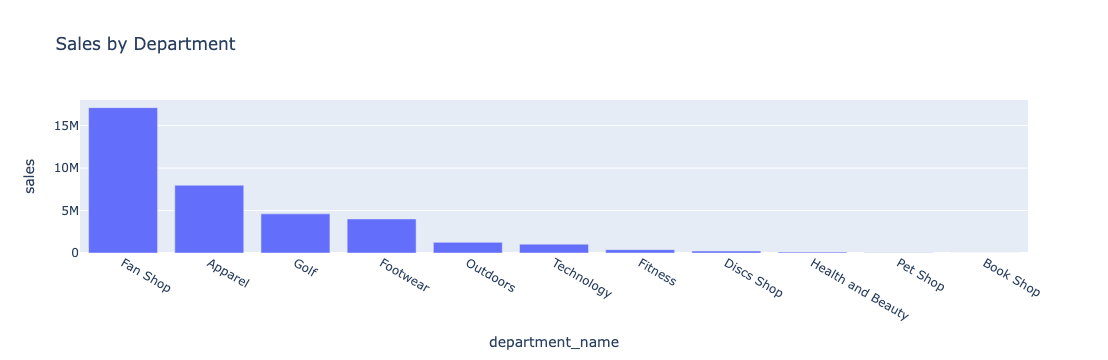

In [66]:
fig = px.bar(
    department_sales,
    x="department_name",
    y="sales",
    title="Sales by Department"
)

fig.show()

# Regional & Market Analysis

## Business Question

Which markets and regions contribute the most to business performance?

In [67]:
region_orders = (
    df.groupby("order_region")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="orders")
)

region_orders

,order_region,orders
0,Western Europe,10010
1,Central America,9396
2,South America,4979
3,Oceania,4362
4,Southeast Asia,4356
5,Northern Europe,3716
6,Southern Europe,3543
7,South Asia,3335
8,Eastern Asia,3318
9,Caribbean,2806


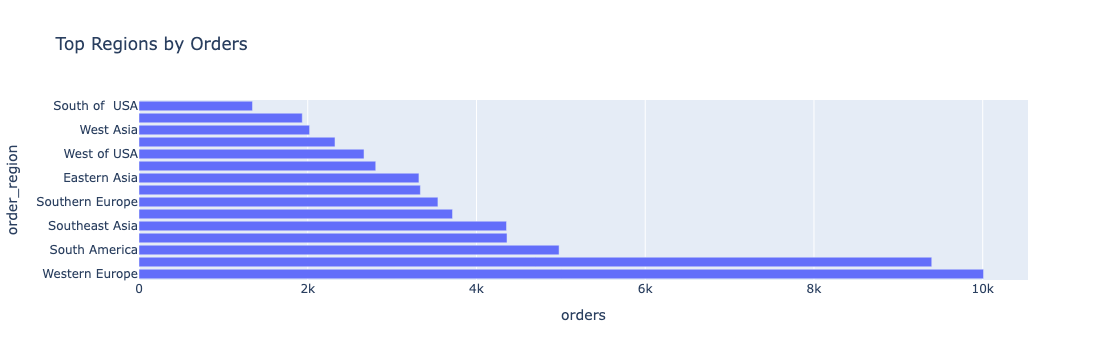

In [68]:
fig = px.bar(
    region_orders,
    x="orders",
    y="order_region",
    orientation="h",
    title="Top Regions by Orders"
)

fig.show()

In [69]:
country_sales = (
    df.groupby("order_country")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

country_sales

,order_country,sales
0,Estados Unidos,4.879668e+06
1,Francia,2.879942e+06
2,México,2.633195e+06
3,Alemania,2.074172e+06
4,Australia,1.694622e+06
5,Reino Unido,1.612095e+06
6,Brasil,1.594320e+06
7,China,1.172902e+06
8,Italia,1.072182e+06
9,India,9.623967e+05


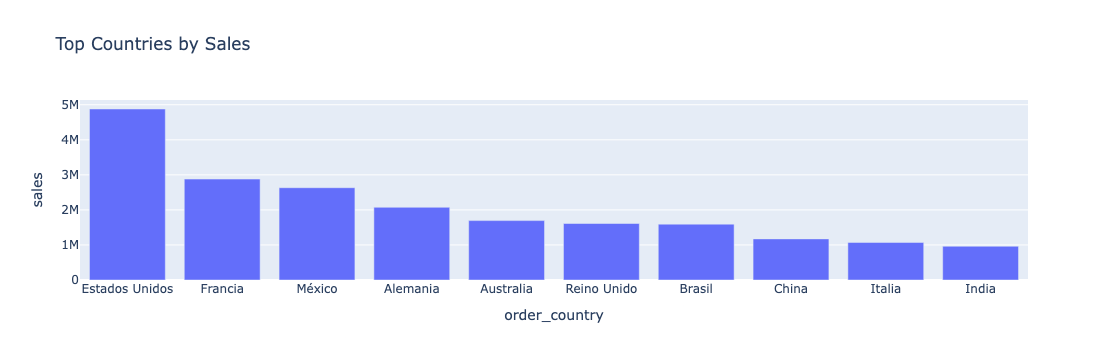

In [70]:
fig = px.bar(
    country_sales,
    x="order_country",
    y="sales",
    title="Top Countries by Sales"
)

fig.show()

In [71]:
market_orders = (
    df.groupby("market")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="orders")
)

market_orders

,market,orders
0,Europe,18561
1,Pacific Asia,17577
2,LATAM,17181
3,USCA,8579
4,Africa,3854


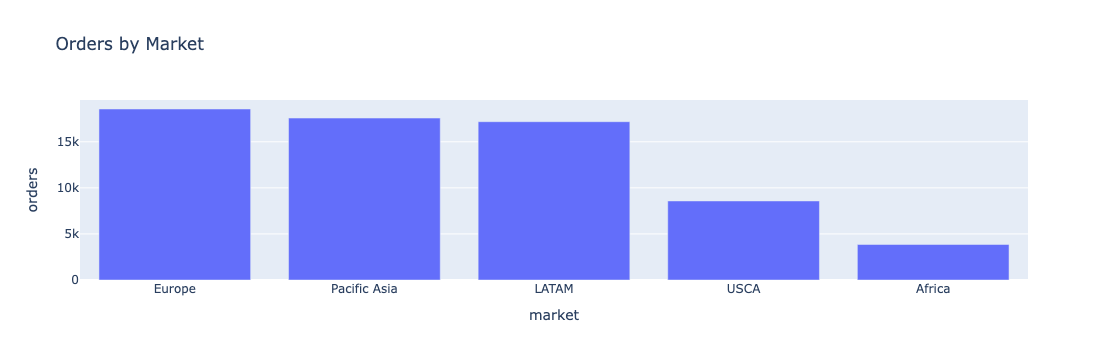

In [72]:
fig = px.bar(
    market_orders,
    x="market",
    y="orders",
    title="Orders by Market"
)

fig.show()

# Operational Performance Analysis

## Business Question

How efficiently are supply chain operations performing?

In [73]:
operational_summary = df.groupby("shipping_mode").agg(
    Total_Orders=("order_id", "nunique"),
    Average_Sales=("sales", "mean"),
    Average_Profit=("order_profit_per_order", "mean"),
    Average_Delivery_Delay=("delivery_delay", "mean")
).reset_index()

operational_summary

,shipping_mode,Total_Orders,Average_Sales,Average_Profit,Average_Delivery_Delay
0,First Class,10079,204.011281,23.122238,1.000000
1,Same Day,3571,199.499698,20.850203,0.478279
2,Second Class,12778,202.903363,21.305889,1.990828
3,Standard Class,39324,204.380354,21.999169,-0.004093


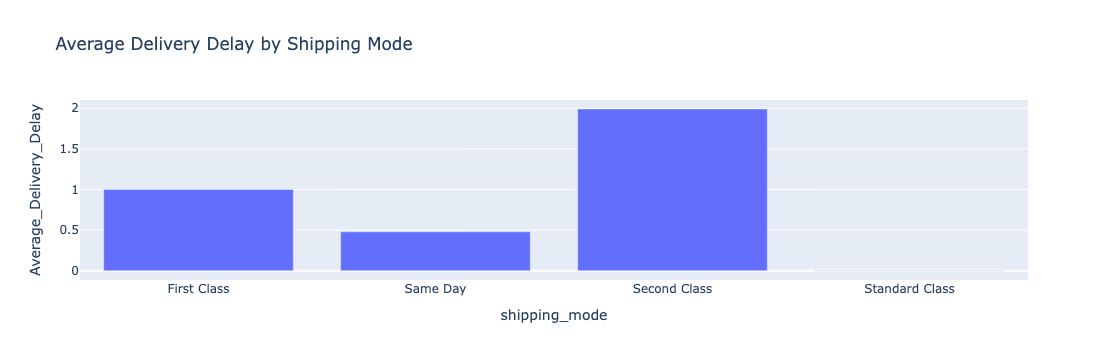

In [74]:
fig = px.bar(
    operational_summary,
    x="shipping_mode",
    y="Average_Delivery_Delay",
    title="Average Delivery Delay by Shipping Mode"
)

fig.show()

In [75]:
operational_summary

,shipping_mode,Total_Orders,Average_Sales,Average_Profit,Average_Delivery_Delay
0,First Class,10079,204.011281,23.122238,1.000000
1,Same Day,3571,199.499698,20.850203,0.478279
2,Second Class,12778,202.903363,21.305889,1.990828
3,Standard Class,39324,204.380354,21.999169,-0.004093


# Exploratory Data Analysis Summary

## Business Insights

- Executive KPIs evaluated
- Sales performance analyzed
- Profitability assessed
- Customer behavior explored
- Product performance evaluated
- Category performance analyzed
- Shipping efficiency measured
- Delivery performance validated
- Regional performance compared
- Market contribution analyzed
- Operational efficiency evaluated

## Conclusion

The exploratory data analysis identified key business trends, operational bottlenecks, and performance drivers across the supply chain. These insights will guide SQL analysis, dashboard development, and executive recommendations in the next phases of the project.

In [3]:
import os

print(os.getcwd())

/Users/anubhavrathore0910/Desktop/LogistiX – Enterprise Supply Chain Intelligence Platform/Python/notebooks


In [4]:
import os

print(os.listdir("../../Dataset"))

['External', 'Interim', 'Processed', 'Raw']


In [5]:
print(os.listdir("../../Dataset/Raw"))

['tokenized_access_logs.csv', '.gitkeep', 'DataCoSupplyChainDataset.csv', 'DescriptionDataCoSupplyChain.csv']


In [7]:
import pandas as pd

df = pd.read_csv(
    "../../Dataset/Raw/DataCoSupplyChainDataset.csv",
    encoding="latin1"
)

print(df.shape)
print(df.columns.tolist())

(180519, 53)
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping d

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [1]:
import pandas as pd

df = pd.read_csv(
    "../../Dataset/Raw/DataCoSupplyChainDataset.csv",
    encoding="latin1"
)

# Random representative sample
sample_df = df.sample(n=10000, random_state=42)

sample_df.to_csv(
    "../../Dashboard/Excel/LogistiX_Excel_Sample.csv",
    index=False
)

print(sample_df.shape)

(10000, 53)


In [1]:
import pandas as pd

df = pd.read_csv(
    "../../Dataset/Raw/DataCoSupplyChainDataset.csv",
    encoding="latin1"
)

print("Rows:", len(df))
print("Unique Order IDs:", df["Order Id"].nunique())
print("Unique Customers:", df["Customer Id"].nunique())


Rows: 180519
Unique Order IDs: 65752
Unique Customers: 20652
